# IRT Item Calibration (Author Items)

Input datasets (from `data/stepwise_cleaned_versions/05_dimensionality_inputs/`):
- `ART_pretest_(for Castano)_EN__dimensionality_input__author_response_matrix.csv` — binary 0/1 matrix (908 × 98 author items)
- `ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv` — item metadata (labels, genres, endorsement rates, cITC, CFA/EFA loadings, flags from step 05)

Output (to `data/stepwise_cleaned_versions/06_irt_item_calibration/`):
- `ART_pretest_(for Castano)_EN__irt_item_parameters.csv` — enriched item table with IRT parameters and flags
- `ART_pretest_(for Castano)_EN__irt_theta_scores.csv` — person ability estimates (EAP theta and SE)

Goals:
1. Fit 1PL (Rasch), 2PL, and 3PL IRT models to all 98 author items using `mirt`
2. Compare models via log-likelihood, AIC, BIC, and likelihood-ratio tests; select best-fitting model
3. Extract item parameters (discrimination _a_, difficulty _b_) and person ability estimates (theta)
4. Plot item characteristic curves (ICCs), test information function (TIF), and conditional standard error (CSE)
5. Export enriched item database with IRT-derived flags for downstream item selection

**Note:** The purpose of this notebook is to assign IRT metric flags to each item so that researchers
can later adjust the Russian ART composition for different populations (e.g., higher education vs.
general participants). This is **not** a final item-selection step.

References:
- Moore & Gordon (2015): compared 1PL, 2PL, 3PL; favored 2PL by likelihood-ratio comparison; used item parameters for test improvement
- McCarron & Kuperman (2022): compared one- through three-parameter models; favored 2PL; used discrimination and difficulty to evaluate ART items across cohorts

In [16]:
library(mirt)
library(psych)
library(ggplot2)
library(reshape2)

mc.cores <- 1
Sys.setenv(MC_CORES = 1)

cat(sprintf("R version: %s.%s \n", R.version$major, R.version$minor))
cat(sprintf("mc.cores: %d (forced serial for IRkernel compatibility)\n", mc.cores))
cat("Package versions:\n")
for (pkg in c("mirt", "psych", "ggplot2", "reshape2")) {
  cat(sprintf("  %-12s %s\n", pkg, as.character(packageVersion(pkg))))
}

R version: 4.5.3 
mc.cores: 1 (forced serial for IRkernel compatibility)
Package versions:
  mirt         1.46.1
  psych        2.6.3
  ggplot2      4.0.2
  reshape2     1.4.5


In [17]:
PROJECT_ROOT <- normalizePath(file.path("..", ".."), mustWork = TRUE)
DATA_DIR     <- file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
                          "05_dimensionality_inputs")
OUTPUT_DIR   <- file.path(PROJECT_ROOT, "data", "stepwise_cleaned_versions",
                          "06_irt_item_calibration")
dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

author_df <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_response_matrix.csv"),
  stringsAsFactors = FALSE)
item_key <- read.csv(file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv"),
  stringsAsFactors = FALSE)

author_mat <- as.matrix(author_df[, -which(names(author_df) == "participant_id")])

cat("\u2500\u2500 Data loaded \u2500\u2500\n")
cat(sprintf("Response matrix : %d participants \u00d7 %d items\n",
            nrow(author_mat), ncol(author_mat)))
cat(sprintf("Item key        : %d items \u00d7 %d columns\n",
            nrow(item_key), ncol(item_key)))
cat(sprintf("All values 0/1  : %s\n",
            all(author_mat %in% c(0, 1, NA))))

col_vars <- apply(author_mat, 2, var, na.rm = TRUE)
constant_cols <- names(col_vars[col_vars == 0])
if (length(constant_cols) > 0) {
  cat(sprintf("WARNING: %d constant columns detected: %s\n",
              length(constant_cols), paste(constant_cols, collapse = ", ")))
} else {
  cat("No constant columns \u2014 all items have variance.\n")
}

── Data loaded ──
Response matrix : 908 participants × 98 items
Item key        : 98 items × 34 columns
All values 0/1  : TRUE
No constant columns — all items have variance.


## 5. IRT Model Fitting: 1PL / 2PL / 3PL

### 5.1 Rationale

ART items differ in both **difficulty** (some authors are widely known, others only to heavy readers)
and **discrimination** (some names separate strong and weak readers well, others do not).
This makes the 2PL model the expected best default for ART data.

Both anchor papers compared alternative IRT models and favored 2PL:
- Moore & Gordon (2015) explicitly report that the 2PL fit better than 1PL and 3PL
- McCarron & Kuperman (2022) report that the 2PL fit better than one-parameter and three-parameter alternatives by likelihood-ratio comparison

We fit all three models below and formally compare them.

### 5.2 Implementation

Using `mirt`:
- **1PL (Rasch)**: constrained equal discrimination
- **2PL**: free discrimination and difficulty
- **3PL**: adds a lower-asymptote (guessing) parameter; requires large N and may not converge well

### 5.3 Statistics to report

For each fitted model:
- Log-likelihood
- AIC, BIC
- Likelihood-ratio comparisons (nested models)
- M2 global fit statistic (if available)
- Convergence status

In [18]:
cat("Fitting 1PL (Rasch) model ...\n")
mod_1pl <- mirt(author_mat, model = 1, itemtype = "Rasch",
                SE = TRUE, verbose = FALSE)
cat(sprintf("  Converged : %s\n", mod_1pl@OptimInfo$converged))
cat(sprintf("  Log-lik   : %.2f\n", extract.mirt(mod_1pl, "logLik")))
cat(sprintf("  AIC       : %.2f\n", extract.mirt(mod_1pl, "AIC")))
cat(sprintf("  BIC       : %.2f\n", extract.mirt(mod_1pl, "BIC")))

Fitting 1PL (Rasch) model ...
  Converged : TRUE
  Log-lik   : -37595.26
  AIC       : 75388.52
  BIC       : 75864.83


In [19]:
cat("Fitting 2PL model ...\n")
mod_2pl <- mirt(author_mat, model = 1, itemtype = "2PL",
                SE = TRUE, verbose = FALSE)
cat(sprintf("  Converged : %s\n", mod_2pl@OptimInfo$converged))
cat(sprintf("  Log-lik   : %.2f\n", extract.mirt(mod_2pl, "logLik")))
cat(sprintf("  AIC       : %.2f\n", extract.mirt(mod_2pl, "AIC")))
cat(sprintf("  BIC       : %.2f\n", extract.mirt(mod_2pl, "BIC")))

Fitting 2PL model ...
  Converged : TRUE
  Log-lik   : -36532.47
  AIC       : 73456.94
  BIC       : 74399.95


In [20]:
cat("Fitting 3PL model ...\n")
cat("(Note: 3PL adds a guessing parameter; may not converge well with N=908.)\n\n")
mod_3pl <- mirt(author_mat, model = 1, itemtype = "3PL",
                SE = TRUE, verbose = FALSE)
cat(sprintf("  Converged : %s\n", mod_3pl@OptimInfo$converged))
cat(sprintf("  Log-lik   : %.2f\n", extract.mirt(mod_3pl, "logLik")))
cat(sprintf("  AIC       : %.2f\n", extract.mirt(mod_3pl, "AIC")))
cat(sprintf("  BIC       : %.2f\n", extract.mirt(mod_3pl, "BIC")))

Fitting 3PL model ...
(Note: 3PL adds a guessing parameter; may not converge well with N=908.)



Warning message:
“EM cycles terminated after 500 iterations.”
Warning message:
“Could not invert information matrix; model may not be (empirically) identified.”


  Converged : FALSE
  Log-lik   : -36435.66
  AIC       : 73459.33
  BIC       : 74873.83


In [21]:
cat("\u2500\u2500 Model comparison table \u2500\u2500\n\n")

comp_df <- data.frame(
  Model      = c("1PL (Rasch)", "2PL", "3PL"),
  Converged  = c(mod_1pl@OptimInfo$converged,
                 mod_2pl@OptimInfo$converged,
                 mod_3pl@OptimInfo$converged),
  LogLik     = c(extract.mirt(mod_1pl, "logLik"),
                 extract.mirt(mod_2pl, "logLik"),
                 extract.mirt(mod_3pl, "logLik")),
  AIC        = c(extract.mirt(mod_1pl, "AIC"),
                 extract.mirt(mod_2pl, "AIC"),
                 extract.mirt(mod_3pl, "AIC")),
  BIC        = c(extract.mirt(mod_1pl, "BIC"),
                 extract.mirt(mod_2pl, "BIC"),
                 extract.mirt(mod_3pl, "BIC")),
  stringsAsFactors = FALSE
)
print(comp_df, row.names = FALSE)

cat("\n\u2500\u2500 Likelihood-ratio tests \u2500\u2500\n\n")
cat("--- 1PL vs 2PL ---\n")
print(anova(mod_1pl, mod_2pl))

cat("\n--- 2PL vs 3PL ---\n")
print(anova(mod_2pl, mod_3pl))

cat("\n\u2500\u2500 M2 global fit (2PL) \u2500\u2500\n")
m2_2pl <- tryCatch(M2(mod_2pl), error = function(e) {
  cat(sprintf("M2 not available: %s\n", e$message)); NULL
})
if (!is.null(m2_2pl)) print(m2_2pl)

── Model comparison table ──

       Model Converged    LogLik      AIC      BIC
 1PL (Rasch)      TRUE -37595.26 75388.52 75864.83
         2PL      TRUE -36532.47 73456.94 74399.95
         3PL     FALSE -36435.66 73459.33 74873.83

── Likelihood-ratio tests ──

--- 1PL vs 2PL ---
             AIC    SABIC       HQ      BIC    logLik       X2 df p
mod_1pl 75388.52 75550.42 75570.40 75864.83 -37595.26              
mod_2pl 73456.95 73777.48 73817.03 74399.95 -36532.47 2125.572 97 0

--- 2PL vs 3PL ---
             AIC    SABIC       HQ      BIC    logLik     X2 df p
mod_2pl 73456.95 73777.48 73817.03 74399.95 -36532.47            
mod_3pl 73459.32 73940.13 73999.45 74873.83 -36435.66 193.62 98 0

── M2 global fit (2PL) ──
            M2   df p RMSEA RMSEA_5 RMSEA_95 SRMSR   TLI   CFI
stats 21273.89 4655 0 0.063   0.062    0.064 0.057 0.931 0.932


### 5.4 Model selection justification

**Interpret after running the cells above.**

Expected outcome based on ART literature:
- 2PL should improve substantially over 1PL (LR test significant, lower AIC/BIC),
  because author items genuinely differ in discrimination.
- 3PL may show marginal improvement in log-likelihood but worse BIC due to the
  98 additional guessing parameters, and convergence may be unstable.
- Both Moore & Gordon and McCarron & Kuperman selected 2PL as the final model.

If the pattern above holds, we proceed with the **2PL model** for all downstream
parameter extraction, ICC plotting, and item flagging.

## 6. Interpreting 2PL Item Parameters

### 6.1 Item difficulty (_b_)

- **Low _b_**: easy item — even low-print-exposure participants recognize the author
- **High _b_**: difficult item — mainly informative for stronger readers

Both papers interpret author-item difficulty in exactly this way.

### 6.2 Item discrimination (_a_)

- **High _a_**: item sharply distinguishes low vs. high print exposure
- **Low _a_**: item contributes little to separating participants

Moore & Gordon used these estimates directly for item evaluation and test improvement;
McCarron & Kuperman used them to compare the usefulness of ART items across cohorts.

In [22]:
params_2pl <- coef(mod_2pl, IRTpars = TRUE, simplify = TRUE)$items
params_df  <- as.data.frame(params_2pl)
params_df$matrix_item_id <- rownames(params_df)

names(params_df)[names(params_df) == "a"]  <- "irt06_2pl_a"
names(params_df)[names(params_df) == "b"]  <- "irt06_2pl_b"
params_df$g <- NULL
params_df$u <- NULL

id_to_label <- setNames(item_key$item_label, item_key$matrix_item_id)
params_df$item_label <- id_to_label[params_df$matrix_item_id]

cat("\u2500\u2500 2PL item parameters (first 10 rows) \u2500\u2500\n")
print(head(params_df[, c("matrix_item_id", "item_label", "irt06_2pl_a", "irt06_2pl_b")], 10))

── 2PL item parameters (first 10 rows) ──
     matrix_item_id             item_label irt06_2pl_a irt06_2pl_b
A001           A001        Khaled Hosseini   1.1502422   1.8412004
A002           A002            Donna Tartt   1.8256588   0.6577460
A003           A003       Archibald Cronin   1.5090684   1.6280262
A004           A004          Gillian Flynn   0.9893217   1.9782469
A005           A005 Gabriel Garsia Marquez   3.4504258  -0.9847713
A006           A006  James Fenimore Cooper   1.5130445  -0.6845954
A007           A007     Henryk Sienkiewicz   2.0785992   0.1605785
A008           A008          Paula Hawkins   0.6902679   3.0457312
A009           A009          George Orwell   1.8213349  -1.9583674
A010           A010            Jane Austen   1.7661192  -1.5811551


── Discrimination (a) summary ──
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.2079  1.2001  1.5942  1.6711  2.0937  3.4504 
  SD: 0.700

── Difficulty (b) summary ──
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-9.0647 -0.8968 -0.1522 -0.1589  0.5183  4.4075 
  SD: 1.810


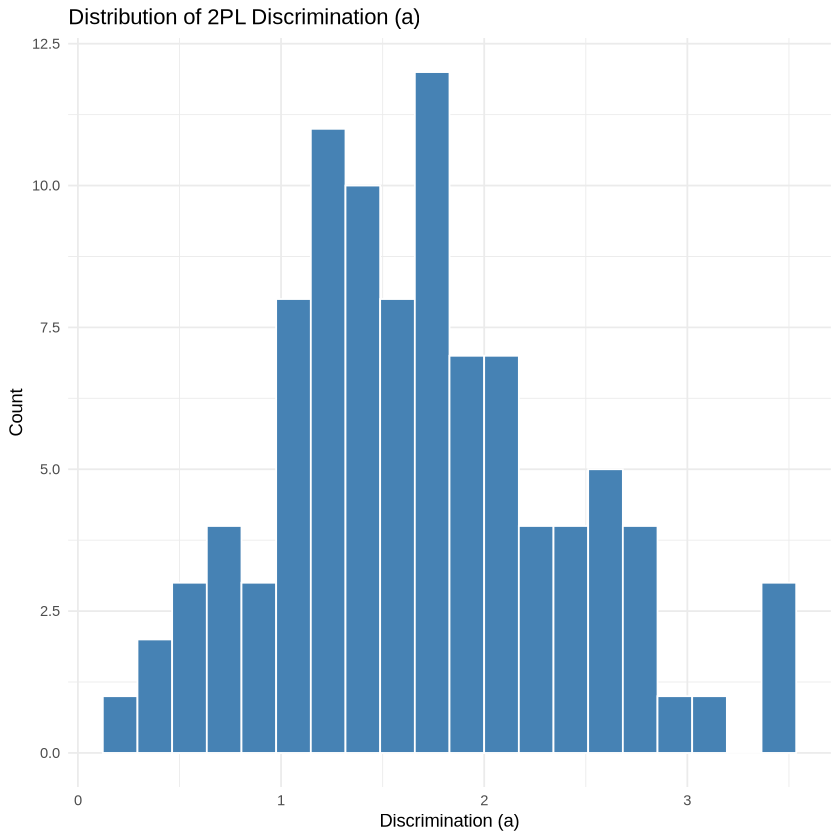


── Extreme-value items ──
  a < 0.5 : 3 items  [Andrzej Sapkovski, Alane Moore, Andrey Belyanin]
  a > 3.0 : 4 items  [Gabriel Garsia Marquez, Somerset Maugham, Milorad Pavic, Victor Pelevin]
  |b| > 3 : 11 items  [Paula Hawkins, Marie - Aude Murai, Arthur Conan Doyle, John R.R. Tolkien, Lee Bardugo, Agatha Christie, Catherine Stokett, Gregory David Roberts, Yustein Gordier, Jules Verne, Reshad Nuri Gyuntekin]


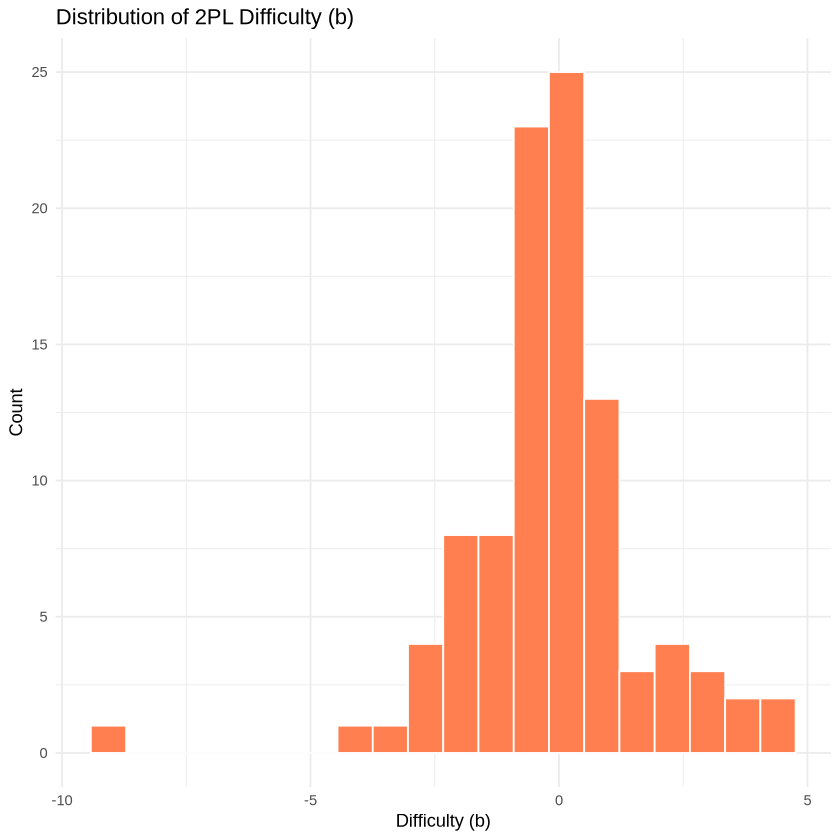

In [23]:
cat("\u2500\u2500 Discrimination (a) summary \u2500\u2500\n")
print(summary(params_df$irt06_2pl_a))
cat(sprintf("  SD: %.3f\n\n", sd(params_df$irt06_2pl_a)))

cat("\u2500\u2500 Difficulty (b) summary \u2500\u2500\n")
print(summary(params_df$irt06_2pl_b))
cat(sprintf("  SD: %.3f\n", sd(params_df$irt06_2pl_b)))

p1 <- ggplot(params_df, aes(x = irt06_2pl_a)) +
  geom_histogram(bins = 20, fill = "steelblue", color = "white") +
  labs(title = "Distribution of 2PL Discrimination (a)",
       x = "Discrimination (a)", y = "Count") +
  theme_minimal()

p2 <- ggplot(params_df, aes(x = irt06_2pl_b)) +
  geom_histogram(bins = 20, fill = "coral", color = "white") +
  labs(title = "Distribution of 2PL Difficulty (b)",
       x = "Difficulty (b)", y = "Count") +
  theme_minimal()

print(p1)
print(p2)

cat("\n\u2500\u2500 Extreme-value items \u2500\u2500\n")
low_a  <- params_df$irt06_2pl_a < 0.5
high_a <- params_df$irt06_2pl_a > 3.0
ext_b  <- abs(params_df$irt06_2pl_b) > 3.0
cat(sprintf("  a < 0.5 : %d items  [%s]\n",
            sum(low_a), paste(params_df$item_label[low_a], collapse = ", ")))
cat(sprintf("  a > 3.0 : %d items  [%s]\n",
            sum(high_a), paste(params_df$item_label[high_a], collapse = ", ")))
cat(sprintf("  |b| > 3 : %d items  [%s]\n",
            sum(ext_b), paste(params_df$item_label[ext_b], collapse = ", ")))

In [24]:
prev_irt_cols <- grep("^irt06_|^flag_irt06_", names(item_key), value = TRUE)
if (length(prev_irt_cols) > 0) {
  item_key <- item_key[, !(names(item_key) %in% prev_irt_cols)]
}

item_key <- merge(item_key,
                  params_df[, c("matrix_item_id", "irt06_2pl_a", "irt06_2pl_b")],
                  by = "matrix_item_id", all.x = TRUE)

item_key$flag_irt06_low_discrimination  <- item_key$irt06_2pl_a < 0.5
item_key$flag_irt06_high_discrimination <- item_key$irt06_2pl_a > 2.5
item_key$flag_irt06_extreme_difficulty   <- abs(item_key$irt06_2pl_b) > 3.0

item_key$irt06_keep_drop_review <- ifelse(
  item_key$flag_irt06_low_discrimination | item_key$flag_citc_negative == "True",
  "drop",
  ifelse(
    item_key$flag_irt06_extreme_difficulty |
      item_key$flag_dim05_cfa_loading_below_020 == TRUE |
      item_key$flag_endorsement_extreme_..05_or_..95 == "True",
    "review",
    "keep"
  )
)

item_key$irt06_rationale <- ifelse(
  item_key$irt06_keep_drop_review == "drop",
  ifelse(item_key$flag_irt06_low_discrimination,
         "low discrimination (a < 0.5)",
         "negative corrected item-total correlation"),
  ifelse(
    item_key$irt06_keep_drop_review == "review",
    paste0(
      ifelse(item_key$flag_irt06_extreme_difficulty, "extreme difficulty; ", ""),
      ifelse(item_key$flag_dim05_cfa_loading_below_020 == TRUE, "CFA loading < .20; ", ""),
      ifelse(item_key$flag_endorsement_extreme_..05_or_..95 == "True",
             "extreme endorsement rate; ", "")
    ),
    ""
  )
)
item_key$irt06_rationale <- trimws(gsub(";\\s*$", "", item_key$irt06_rationale))

cat("\u2500\u2500 Keep / Drop / Review tally \u2500\u2500\n")
print(table(item_key$irt06_keep_drop_review))

ERROR: Error in `$<-.data.frame`(`*tmp*`, flag_irt06_low_discrimination, value = logical(0)): replacement has 0 rows, data has 98


In [ ]:
display_cols <- c("matrix_item_id", "item_label", "genre",
                  "selection_rate_pct", "corrected_item_total_corr",
                  "dim05_cfa_loading_full",
                  "irt06_2pl_a", "irt06_2pl_b",
                  "irt06_keep_drop_review", "irt06_rationale")

decision_tbl <- item_key[, display_cols]
decision_tbl <- decision_tbl[order(decision_tbl$irt06_keep_drop_review,
                                   -decision_tbl$irt06_2pl_a), ]

cat("\u2500\u2500 Item decision table (sorted by decision, then discrimination desc) \u2500\u2500\n\n")
print(decision_tbl, row.names = FALSE, right = FALSE)

## 7. ICCs, Information, and Measurement Precision

### 7.1 Item characteristic curves (ICCs)

ICCs show the probability of endorsing each author as a function of latent print exposure (theta).
We plot subsets of items to illustrate the range of difficulty and discrimination:
- **Easiest 10** (lowest _b_)
- **Hardest 10** (highest _b_)
- **Highest-discrimination 10** (highest _a_)
- **Lowest-discrimination 10** (lowest _a_)

Moore & Gordon and McCarron & Kuperman both use ICCs to show what kinds of readers each item is informative for.

### 7.2 Test information function (TIF)

The TIF shows where the Russian ART measures best across the theta continuum.
Moore & Gordon concluded that ART was more informative at the higher end and suggested adding easier items.
McCarron & Kuperman show that some cohorts had poor information and large error at low theta.

### 7.3 Conditional standard error (CSE)

SE(theta) shows measurement precision across the ability range. This is one of the most
useful outputs because it reveals whether the Russian ART is precise for:
- Low-literacy / low-reading participants
- Average readers
- Heavy readers

McCarron & Kuperman's paper strongly supports including this plot.

In [ ]:
sorted_b <- params_df[order(params_df$irt06_2pl_b), ]
sorted_a <- params_df[order(params_df$irt06_2pl_a), ]

easiest_10  <- sorted_b$matrix_item_id[1:10]
hardest_10  <- sorted_b$matrix_item_id[(nrow(sorted_b) - 9):nrow(sorted_b)]
highest_a10 <- sorted_a$matrix_item_id[(nrow(sorted_a) - 9):nrow(sorted_a)]
lowest_a10  <- sorted_a$matrix_item_id[1:10]

theta_grid <- matrix(seq(-4, 4, length.out = 200), ncol = 1)

id_to_label <- setNames(item_key$item_label, item_key$matrix_item_id)

plot_icc_subset <- function(mod, item_ids, title) {
  item_nums <- which(colnames(author_mat) %in% item_ids)
  probs_list <- list()
  for (i in item_nums) {
    item_code <- colnames(author_mat)[i]
    label <- id_to_label[item_code]
    p <- probtrace(extract.item(mod, i), theta_grid)[, 2]
    probs_list[[label]] <- p
  }
  plot_df <- data.frame(
    theta = rep(theta_grid[, 1], length(probs_list)),
    prob  = unlist(probs_list),
    item  = rep(names(probs_list), each = nrow(theta_grid))
  )
  ggplot(plot_df, aes(x = theta, y = prob, color = item)) +
    geom_line(linewidth = 0.6) +
    labs(title = title, x = expression(theta), y = "P(X = 1)") +
    theme_minimal() +
    theme(legend.position = "right",
          legend.text = element_text(size = 7))
}

print(plot_icc_subset(mod_2pl, easiest_10,
                      "ICCs: 10 Easiest Items (lowest b)"))
print(plot_icc_subset(mod_2pl, hardest_10,
                      "ICCs: 10 Hardest Items (highest b)"))
print(plot_icc_subset(mod_2pl, highest_a10,
                      "ICCs: 10 Highest-Discrimination Items (highest a)"))
print(plot_icc_subset(mod_2pl, lowest_a10,
                      "ICCs: 10 Lowest-Discrimination Items (lowest a)"))

In [ ]:
theta_seq  <- seq(-4, 4, length.out = 200)
info_vals  <- testinfo(mod_2pl, matrix(theta_seq, ncol = 1))

tif_df <- data.frame(theta = theta_seq, information = info_vals)

peak_theta <- theta_seq[which.max(info_vals)]
peak_info  <- max(info_vals)

p_tif <- ggplot(tif_df, aes(x = theta, y = information)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_vline(xintercept = peak_theta, linetype = "dashed", color = "grey40") +
  annotate("text", x = peak_theta + 0.3, y = peak_info * 0.95,
           label = sprintf("Peak at \u03b8 = %.2f", peak_theta),
           hjust = 0, size = 3.5) +
  labs(title = "Test Information Function (2PL)",
       x = expression(theta), y = "Information") +
  theme_minimal()
print(p_tif)

cat(sprintf("Peak information: %.2f at theta = %.2f\n", peak_info, peak_theta))
cat(sprintf("Information at theta = -2: %.2f\n", testinfo(mod_2pl, matrix(-2, ncol = 1))))
cat(sprintf("Information at theta =  0: %.2f\n", testinfo(mod_2pl, matrix( 0, ncol = 1))))
cat(sprintf("Information at theta = +2: %.2f\n", testinfo(mod_2pl, matrix( 2, ncol = 1))))

In [ ]:
se_vals <- 1 / sqrt(info_vals)
se_df   <- data.frame(theta = theta_seq, se = se_vals)

p_se <- ggplot(se_df, aes(x = theta, y = se)) +
  geom_line(linewidth = 1, color = "coral") +
  geom_hline(yintercept = 1 / sqrt(peak_info), linetype = "dashed",
             color = "grey40") +
  labs(title = "Conditional Standard Error of Measurement (2PL)",
       x = expression(theta), y = "SE(\u03b8)") +
  theme_minimal()
print(p_se)

cat(sprintf("SE at theta = -2: %.3f\n", 1 / sqrt(testinfo(mod_2pl, matrix(-2, ncol = 1)))))
cat(sprintf("SE at theta =  0: %.3f\n", 1 / sqrt(testinfo(mod_2pl, matrix( 0, ncol = 1)))))
cat(sprintf("SE at theta = +2: %.3f\n", 1 / sqrt(testinfo(mod_2pl, matrix( 2, ncol = 1)))))

In [ ]:
theta_mat <- fscores(mod_2pl, method = "EAP", full.scores.SE = TRUE)

theta_df <- data.frame(
  participant_id = author_df$participant_id,
  irt06_theta    = theta_mat[, 1],
  irt06_theta_se = theta_mat[, 2]
)

cat("\u2500\u2500 Theta (EAP) summary \u2500\u2500\n")
print(summary(theta_df$irt06_theta))
cat(sprintf("  SD: %.3f\n\n", sd(theta_df$irt06_theta)))

cat("\u2500\u2500 Theta SE summary \u2500\u2500\n")
print(summary(theta_df$irt06_theta_se))

p_theta <- ggplot(theta_df, aes(x = irt06_theta)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Person Ability Estimates (EAP Theta)",
       x = expression(theta), y = "Count") +
  theme_minimal()
print(p_theta)

In [ ]:
item_out <- file.path(OUTPUT_DIR,
  "ART_pretest_(for Castano)_EN__irt_item_parameters.csv")
write.csv(item_key, item_out, row.names = FALSE)

theta_out <- file.path(OUTPUT_DIR,
  "ART_pretest_(for Castano)_EN__irt_theta_scores.csv")
write.csv(theta_df, theta_out, row.names = FALSE)

author_key_path <- file.path(DATA_DIR,
  "ART_pretest_(for Castano)_EN__dimensionality_input__author_item_key.csv")
write.csv(item_key, author_key_path, row.names = FALSE)

irt06_cols <- grep("^irt06_|^flag_irt06_", names(item_key), value = TRUE)

cat("\u2500\u2500 Export summary \u2500\u2500\n\n")
cat(sprintf("Item parameters : %s\n", basename(item_out)))
cat(sprintf("  Rows: %d | Total columns: %d | New irt06 columns: %d\n",
            nrow(item_key), ncol(item_key), length(irt06_cols)))
cat(sprintf("  New columns: %s\n\n", paste(irt06_cols, collapse = ", ")))

cat(sprintf("Theta scores    : %s\n", basename(theta_out)))
cat(sprintf("  Rows: %d | Columns: %d\n\n", nrow(theta_df), ncol(theta_df)))

cat(sprintf("Updated item key: %s\n", basename(author_key_path)))
cat(sprintf("  (in %s)\n", basename(DATA_DIR)))

cat("\nDone. Re-run notebook to regenerate identical outputs.\n")